# Modulation e Demodulation
## Carrier Signal

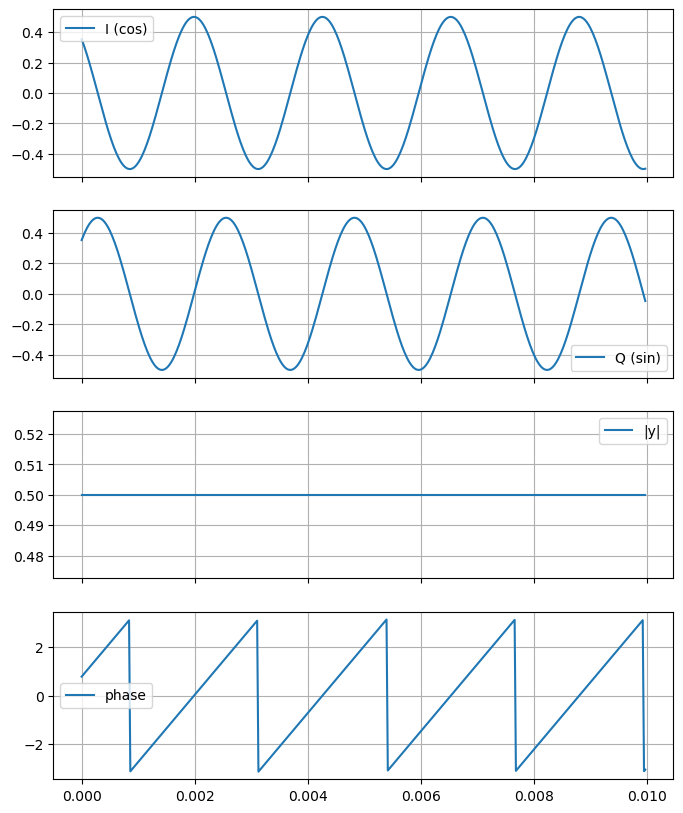

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
a = 0.5
phi = np.deg2rad(45)

fc = 440       # frequência audível (Hz)
fs = 44100     # sampling rate

x = np.arange(0, 0.01, 1/fs)

# I/Q
i = a * np.cos(2*np.pi*fc*x + phi)
q = a * np.sin(2*np.pi*fc*x + phi)

y = i + 1j*q

# plots
fig, axs = plt.subplots(4,1, figsize=(8,10), sharex=True)

axs[0].plot(x, i, label="I (cos)")
axs[1].plot(x, q, label="Q (sin)")
axs[2].plot(x, np.abs(y), label="|y|")
axs[3].plot(x, np.angle(y), label="phase")

for ax in axs:
    ax.legend()
    ax.grid(True)

plt.show()

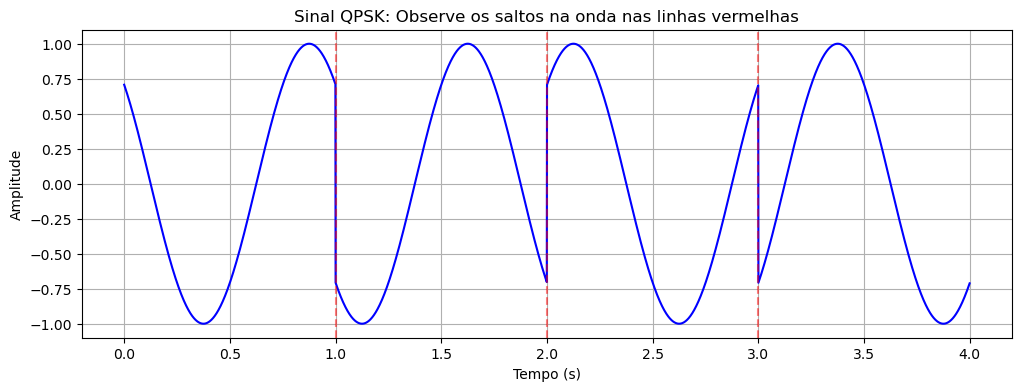

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurações do Sistema
fs = 1000          # Frequência de amostragem
fc = 1           # Frequência da Portadora (10 ciclos por segundo)
bits = [0, 0, 0, 1, 1, 0, 1, 1] # Sequência de dados (4 pares)
T = 1            # Duração de cada par de bits (segundos)
t_segmento = np.linspace(0, T, int(fs * T), endpoint=False) # 

# 2. Dicionário de Fases (Mapeamento QPSK)
# Definimos os "pulos" iniciais para cada combinação de 2 bits
mapeamento = {
    (0, 0): np.pi/4,   # 45 graus
    (0, 1): 3*np.pi/4, # 135 graus
    (1, 1): 5*np.pi/4, # 225 graus
    (1, 0): 7*np.pi/4  # 315 graus
}

sinal_total = []
eixo_tempo = []

# 3. Processamento dos Bits
for i in range(0, len(bits), 2):
    par = tuple(bits[i:i+2])
    fase = mapeamento[par]
    
    # Gerando a portadora com o "pulo" de fase específico
    onda = np.cos(2 * np.pi * fc * t_segmento + fase)
    
    sinal_total.extend(onda)
    # Ajuste do eixo de tempo contínuo
    tempo_atual = i/2 * T
    eixo_tempo.extend(t_segmento + tempo_atual)

# 4. Visualização
plt.figure(figsize=(12, 4))
plt.plot(eixo_tempo, sinal_total, color='blue', linewidth=1.5)

# Linhas verticais para marcar onde os bits mudam
for i in range(1, len(bits)//2):
    plt.axvline(x=i*T, color='red', linestyle='--', alpha=0.5)

plt.title('Sinal QPSK: Observe os saltos na onda nas linhas vermelhas')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [12]:
import math

class SimuladorLatenciaV2X:
    def __init__(self):
        # Constantes de sistema (Referência)
        self.N0_dBm_Hz = -174
    
    @staticmethod
    def dbm_para_linear_w(potencia_dbm):
        """Converte dBm para Watts (escala linear)."""
        return 10 ** ((potencia_dbm - 30) / 10)

    @staticmethod
    def linear_w_para_dbm(potencia_w):
        """Converte Watts (escala linear) para dBm."""
        if potencia_w <= 0: return float('-inf')
        return 10 * math.log10(potencia_w) + 30

    def calcular_tempo_tx_discreto(self, L_bits, bits_por_slot, T_slot_ms):
        """Calcula o tempo de transmissão quantizado via slots (Abordagem Prática)."""
        N_slots = math.ceil(L_bits / bits_por_slot)
        return N_slots * T_slot_ms

    def calcular_tempo_processamento_ue(self, mu, ue_capability="normal", channel_type="PUSCH"):
        """
        Calcula o T_proc normativo baseado no 3GPP (em milissegundos).
        Usa o número de símbolos definidos em norma para a capacidade do UE.
        """
        if channel_type == "PUSCH":
            # Tabela 11.6: Minimum PUSCH preparation time
            tabela_simbolos = {
                0: {"normal": 10, "low_latency": 5},
                1: {"normal": 12, "low_latency": 5.5},
                2: {"normal": 23, "low_latency": 11},
                3: {"normal": 36, "low_latency": float('inf')} # Não suportado
            }
        elif channel_type == "PDSCH":
            # Tabela 11.7: Minimum PDSCH processing time
            tabela_simbolos = {
                0: {"normal": 8,  "low_latency": 3},
                1: {"normal": 10, "low_latency": 4.5},
                2: {"normal": 17, "low_latency": 9},
                3: {"normal": 20, "low_latency": float('inf')}
            }
        else:
            raise ValueError("Tipo de canal inválido.")

        n_symb = tabela_simbolos[mu][ue_capability]
        
        if n_symb == float('inf'):
            return float('inf')

        t_slot_ms = 2**(-mu)
        t_symb_ms = t_slot_ms / 14 # 1 slot padrão possui sempre 14 símbolos

        return n_symb * t_symb_ms

    def calcular_latencia_v2i(self, T_tx_ms, T_proc_ms, T_prop_ms, N_harq, T_rtt_harq_ms):
        """Calcula o atraso real no cenário V2I Uu."""
        return T_tx_ms + T_proc_ms + T_prop_ms + (N_harq * T_rtt_harq_ms)

    def calcular_latencia_sidelink_pc5(self, T_sensing_ms, T_tx_sl_ms, T_proc_ms, T_prop_ms, N_harq_sl, T_rtt_psfch_ms):
        """Calcula a latência fim-a-fim no Sidelink Modo 2."""
        # Adicionado o T_proc_ms físico do terminal para manter a simetria com a modelagem do 3GPP
        T_e2e_sl = T_sensing_ms + T_tx_sl_ms + T_proc_ms + T_prop_ms
        return T_e2e_sl + (N_harq_sl * T_rtt_psfch_ms)


simulador = SimuladorLatenciaV2X()

# ---------------------------------------------------------
# CENÁRIO 1: 5G V2I (Interface Uu via Estação Base)
# ---------------------------------------------------------
print("--- Resultados: Cenário 5G V2I Otimizado por Norma ---")
L_bits_v2i = 12000
capacidade_slot_v2i = 8000
mu = 2 # Numerologia (60 kHz)
T_slot_v2i_v2x = 2**-mu # Regra de 2^(-mu) é universal

# Tempos Físicos
T_tx_v2i = simulador.calcular_tempo_tx_discreto(L_bits_v2i, capacidade_slot_v2i, T_slot_v2i_v2x)
T_prop_ms = 0.001 
T_proc_v2i = simulador.calcular_tempo_processamento_ue(mu=mu, ue_capability="low_latency", channel_type="PUSCH")

# Condições de Canal (Retransmissões)
N_harq_v2i = 1
T_rtt_harq_v2i_ms = 2.0

T_up_real = simulador.calcular_latencia_v2i(
    T_tx_ms=T_tx_v2i, 
    T_proc_ms=T_proc_v2i, 
    T_prop_ms=T_prop_ms, 
    N_harq=N_harq_v2i, 
    T_rtt_harq_ms=T_rtt_harq_v2i_ms
)

print(f"Duração do Slot (mu={mu}): {T_slot_v2i_v2x:.4f} ms")
print(f"Tempo de Transmissão Nominal (T_tx): {T_tx_v2i:.4f} ms")
print(f"Tempo de Processamento Físico do UE (T_proc): {T_proc_v2i:.4f} ms")
print(f"Latência Final V2I (T_UP_real): {T_up_real:.4f} ms")


# ---------------------------------------------------------
# CENÁRIO 2: 5G C-V2X (Sidelink PC5 Direto V2V)
# ---------------------------------------------------------
print("\n--- Resultados: Cenário 5G C-V2X PC5 (Sidelink) ---")
L_bits_sl = 12000
capacidade_slot_sl = 8000

# Como o Sidelink herda a arquitetura OFDM do Uu, os dados base de Tx são idênticos:
T_tx_sl = simulador.calcular_tempo_tx_discreto(L_bits_sl, capacidade_slot_sl, T_slot_v2i_v2x)
T_prop_sl = 0.0 # Aproximação local para distâncias muito curtas (veículo-veículo)
T_proc_sl = simulador.calcular_tempo_processamento_ue(mu=mu, ue_capability="low_latency", channel_type="PUSCH")

# Variáveis estritas do Sidelink Modo 2 (Sem agendador central)
T_sensing = 10.0 # O veículo gasta ms ouvindo o canal antes de enviar
N_harq_sl = 2    # Sombreamento dinâmico severo por bloqueio (ex: caminhão) N_max definido, não calculado
T_rtt_psfch_ms = 3.0 # Feedback via canal Sidelink PSFCH

T_lat_pc5 = simulador.calcular_latencia_sidelink_pc5(
    T_sensing_ms=T_sensing, 
    T_tx_sl_ms=T_tx_sl, 
    T_proc_ms=T_proc_sl,
    T_prop_ms=T_prop_sl, 
    N_harq_sl=N_harq_sl, 
    T_rtt_psfch_ms=T_rtt_psfch_ms
)

print(f"Duração do Slot (mu={mu}): {T_slot_v2i_v2x:.4f} ms")
print(f"Tempo de Transmissão Nominal SL (T_tx): {T_tx_sl:.4f} ms")
print(f"Tempo de Processamento Físico do UE SL (T_proc): {T_proc_sl:.4f} ms")
print(f"Penalidade de Sensoriamento de Canal (T_sensing): {T_sensing:.4f} ms")
print(f"Latência Final PC5 com falhas HARQ: {T_lat_pc5:.4f} ms")


--- Resultados: Cenário 5G V2I Otimizado por Norma ---
Duração do Slot (mu=2): 0.2500 ms
Tempo de Transmissão Nominal (T_tx): 0.5000 ms
Tempo de Processamento Físico do UE (T_proc): 0.1964 ms
Latência Final V2I (T_UP_real): 2.6974 ms

--- Resultados: Cenário 5G C-V2X PC5 (Sidelink) ---
Duração do Slot (mu=2): 0.2500 ms
Tempo de Transmissão Nominal SL (T_tx): 0.5000 ms
Tempo de Processamento Físico do UE SL (T_proc): 0.1964 ms
Penalidade de Sensoriamento de Canal (T_sensing): 10.0000 ms
Latência Final PC5 com falhas HARQ: 16.6964 ms
